# 站点地理信息可视化分析

本笔记本结合 `data/raw/geo_data/stations.csv` 中的地理信息，分析 `data/processed/all_data.parquet` 中涉及的112个站点的分布情况。

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

# 读取地理数据
geo_df = pd.read_csv('../data/raw/geo_data/stations.csv')

# 读取气象数据
meteo_df = pd.read_parquet('../data/processed/all_data.parquet')

# 从气象数据列名中提取站点代码
stations_in_meteo = set([col.split('~')[0] for col in meteo_df.columns])
stations_in_meteo = sorted(list(stations_in_meteo))

print(f'气象数据中包含的站点数: {len(stations_in_meteo)}')
print(f'地理数据中包含的站点数: {len(geo_df)}')

气象数据中包含的站点数: 112
地理数据中包含的站点数: 302


## 1. 站点匹配分析

In [8]:
# 提取地理数据中的站点代码
stations_in_geo = set(geo_df['nat_abbr'])

# 检查匹配情况
matched_stations = set(stations_in_meteo) & stations_in_geo
unmatched_stations = set(stations_in_meteo) - stations_in_geo

print(f'匹配的站点数: {len(matched_stations)}')
print(f'未匹配的站点数: {len(unmatched_stations)}')

if unmatched_stations:
    print('未匹配的站点:', sorted(list(unmatched_stations)))

# 过滤出匹配的地理数据
matched_geo_df = geo_df[geo_df['nat_abbr'].isin(stations_in_meteo)].copy()
print(f'匹配后的地理数据行数: {len(matched_geo_df)}')

匹配的站点数: 112
未匹配的站点数: 0
匹配后的地理数据行数: 112


## 2. 站点地理分布

In [9]:
import folium
from folium.plugins import MarkerCluster

# 创建地图
m = folium.Map(location=[46.8, 8.2], zoom_start=8, tiles='OpenStreetMap')

# 添加站点标记
marker_cluster = MarkerCluster().add_to(m)

for idx, row in matched_geo_df.iterrows():
    station_code = row['nat_abbr']
    station_name = row['station_name']
    lat = row['latitude']
    lon = row['longitude']
    elevation = row['station_height']
    station_type = row['station_type']
    
    # 弹出信息
    popup_content = f'<b>站点代码:</b> {station_code}<br><b>站点名称:</b> {station_name}<br><b>纬度:</b> {lat}<br><b>经度:</b> {lon}<br><b>海拔:</b> {elevation} m<br><b>站点类型:</b> {station_type}<br>'
    
    # 根据站点类型设置不同颜色
    if station_type == 'meteo_station':
        color = 'blue'
    elif station_type == 'rain_gauge':
        color = 'green'
    else:
        color = 'red'
    
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_content, max_width=300),
        icon=folium.Icon(color=color, icon='info-sign')
    ).add_to(marker_cluster)

# 保存地图为HTML文件
m.save('../data/figs/stations_map.html')
print('站点分布图已保存到 ../data/figs/stations_map.html')

# 在笔记本中显示地图
m

站点分布图已保存到 ../data/figs/stations_map.html


## 3. 站点海拔分布

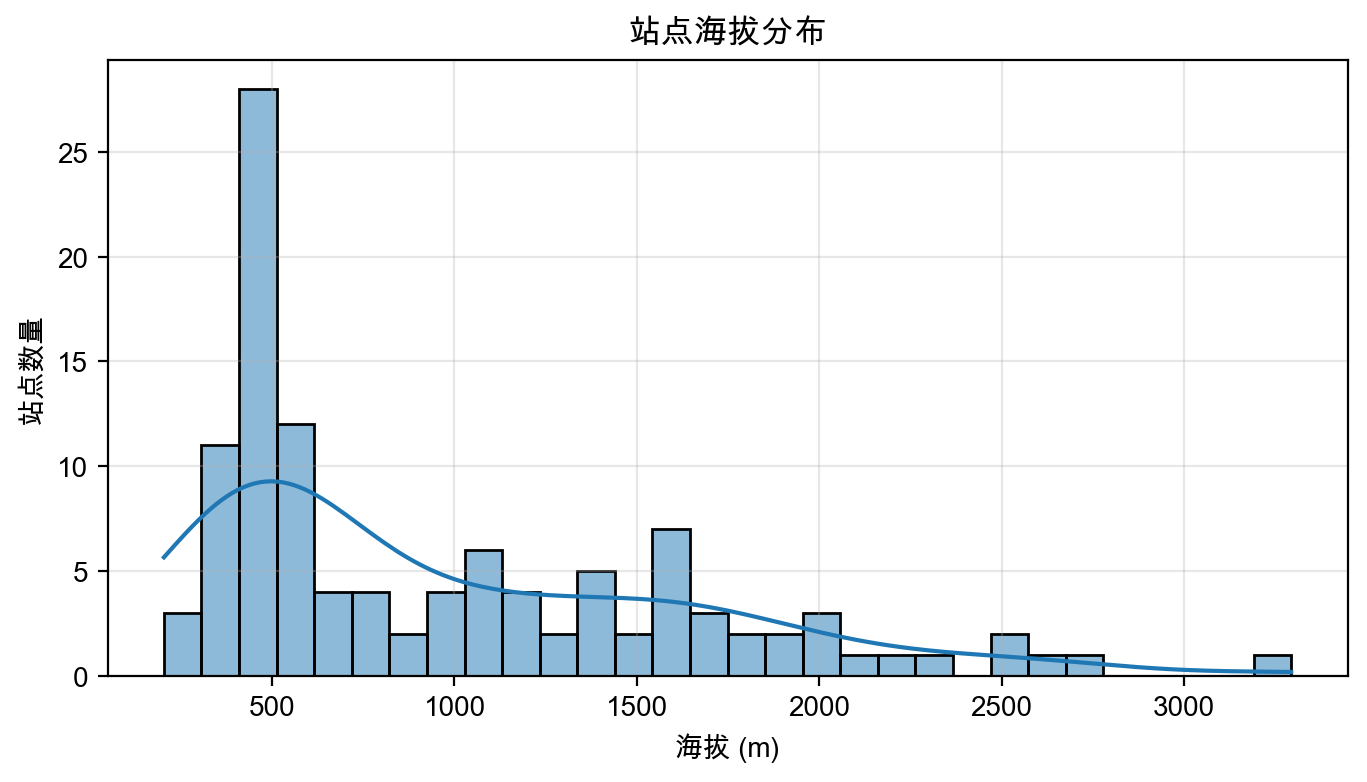

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(matched_geo_df['station_height'], bins=30, kde=True)
plt.title('站点海拔分布')
plt.xlabel('海拔 (m)')
plt.ylabel('站点数量')
plt.grid(True, alpha=0.3)
plt.show()

## 4. 站点空间密度分析

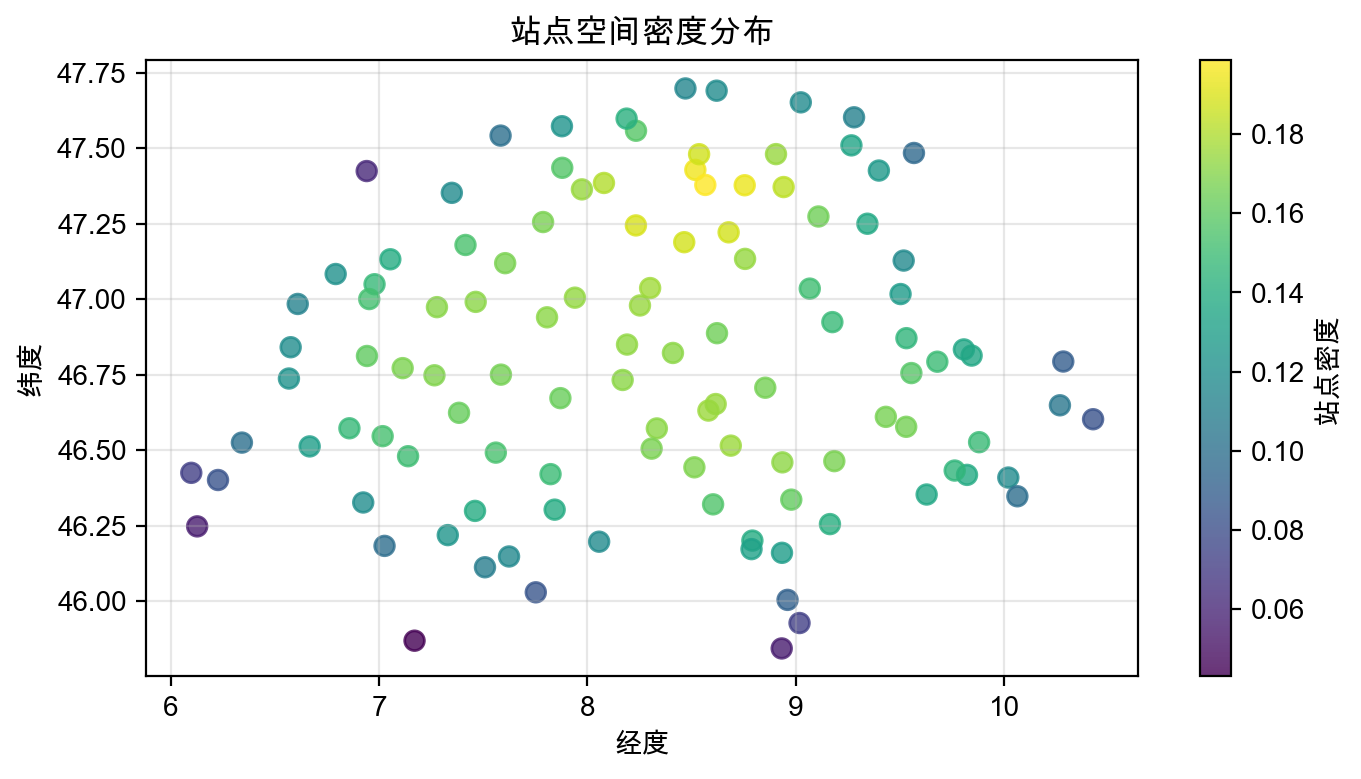

In [11]:
from scipy.stats import gaussian_kde

# 计算核密度估计
x = matched_geo_df['longitude']
y = matched_geo_df['latitude']
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
z = kde(xy)

plt.figure(figsize=(8, 4))
scatter = plt.scatter(x, y, c=z, s=50, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='站点密度')
plt.title('站点空间密度分布')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.grid(True, alpha=0.3)
plt.show()

## 5. 分析总结

In [ ]:
print('=== 分析总结 ===')
print(f'1. 气象数据包含站点数: {len(stations_in_meteo)}')
print(f'2. 匹配的地理数据站点数: {len(matched_geo_df)}')
print(f'3. 站点类型分布:')
for station_type, count in station_type_counts.items():
    print(f'   - {station_type}: {count}个')
print(f'4. 海拔范围: {matched_geo_df['station_height'].min():.1f}m - {matched_geo_df['station_height'].max():.1f}m')
print(f'5. 平均海拔: {matched_geo_df['station_height'].mean():.1f}m')
print(f'6. 每个站点平均变量数: {var_count_df['var_count'].mean():.1f}')

=== 分析总结 ===
1. 气象数据包含站点数: 112
2. 匹配的地理数据站点数: 112
3. 站点类型分布:
   - meteo_station: 112个
4. 海拔范围: 203.2m - 3294.3m
5. 平均海拔: 973.3m
6. 每个站点平均变量数: 8.0
